# ScanRefer Eval Results Analysis

Loads a results JSON produced by `scripts/eval_scanrefer_unique.py` and shows:
1. **Overall summary** — Acc@0.25 / Acc@0.50, IoU distribution, timing
2. **Per-scene breakdown** — hit rates per scene, sorted by performance
3. **Per-object-category breakdown** — which categories are hardest
4. **IoU histogram and CDF**
5. **Failure analysis** — worst-performing items

In [13]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ──────────────────────────────────────────────────────────────────
RESULTS_FILE   = Path("../eval_results_scanrefer_obj.json")  # adjust as needed
IOU_THRESHOLDS = [0.25, 0.50]
MIN_CAT_COUNT  = 3   # minimum queries per category to appear in category plots

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

In [14]:
raw = json.loads(RESULTS_FILE.read_text())

df = pd.DataFrame(raw["items"])
df["category"] = df["object_name"].str.replace("_", " ").str.strip().str.lower()

print(f"Query mode : {raw['query_mode']}")
print(f"N items    : {len(df)}")
print(f"N scenes   : {df['scene_id'].nunique()}")
print(f"N categories: {df['category'].nunique()}")
df.head(3)

Query mode : object_name
N items    : 722
N scenes   : 134
N categories: 132


,scene_id,object_id,object_name,ann_id,query_text,iou,query_time_s,hit@0.25,hit@0.50,category
0,scene0011_00,1,kitchen_cabinets,dedup,kitchen cabinets,0.0410,20.641,False,False,kitchen cabinets
1,scene0011_00,18,tv,dedup,tv,0.7935,17.823,True,True,tv
2,scene0011_00,25,kitchen_counter,dedup,kitchen counter,0.4633,17.969,True,False,kitchen counter


## 1 · Overall Summary

In [15]:
n = len(df)

print("── Accuracy ──────────────────────────────")
for thr in IOU_THRESHOLDS:
    col  = f"hit@{thr:.2f}"
    hits = df[col].sum()
    print(f"  Acc@{thr:.2f}  : {hits:4d}/{n}  = {hits/n:.3f}")

print("\n── IoU statistics ────────────────────────")
print(df["iou"].describe().to_string())

print("\n── Timing ────────────────────────────────")
t = df["query_time_s"]
print(f"  total    : {t.sum():.1f}s  ({t.sum()/3600:.2f}h)")
print(f"  avg/query: {t.mean():.2f}s")
print(f"  median   : {t.median():.2f}s")

── Accuracy ──────────────────────────────
  Acc@0.25  :  378/722  = 0.524
  Acc@0.50  :  200/722  = 0.277

── IoU statistics ────────────────────────
count    722.000000
mean       0.295735
std        0.264240
min        0.000000
25%        0.008550
50%        0.284450
75%        0.523225
max        0.928100

── Timing ────────────────────────────────
  total    : 13610.1s  (3.78h)
  avg/query: 18.85s
  median   : 18.80s


## 2 · IoU Distribution

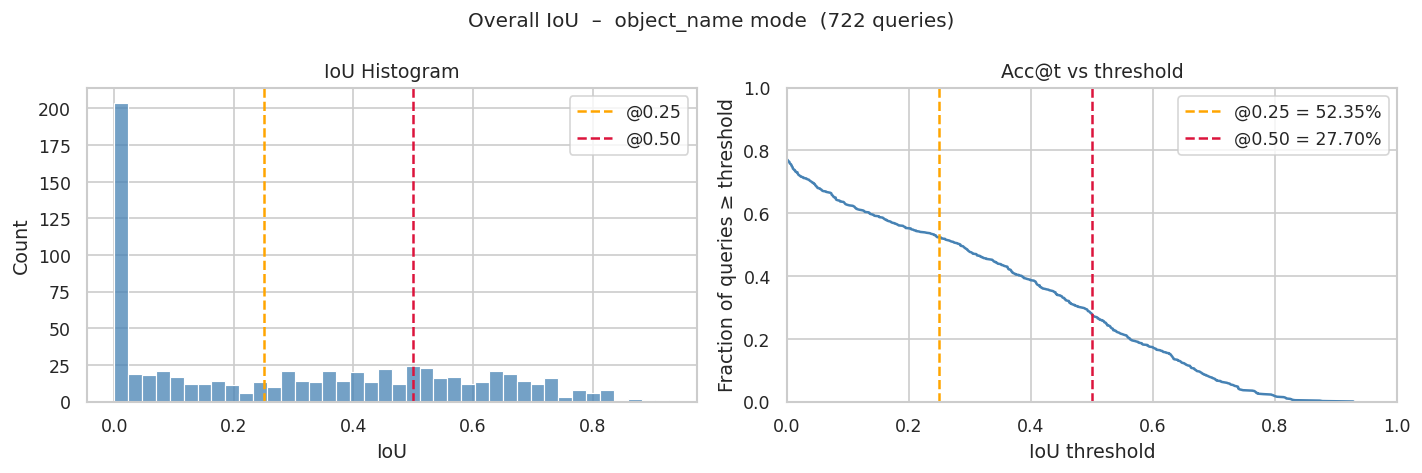

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
ax = axes[0]
sns.histplot(df["iou"], bins=40, ax=ax, color="steelblue")
for thr, color in zip(IOU_THRESHOLDS, ["orange", "crimson"]):
    ax.axvline(thr, color=color, linewidth=1.5, linestyle="--", label=f"@{thr:.2f}")
ax.set(xlabel="IoU", ylabel="Count", title="IoU Histogram")
ax.legend()

# CDF
ax = axes[1]
sns.ecdfplot(df["iou"], ax=ax, color="steelblue")
# ecdfplot shows P(X ≤ x); flip to Acc@t = P(X ≥ t)
ax.set(xlabel="IoU threshold", ylabel="Fraction of queries ≥ threshold",
       title="IoU CDF  (= Acc@t as a function of t)", xlim=(0, 1))
ax.yaxis.set_inverted(True)   # flip so higher = better at left
ax.yaxis.set_inverted(False)
# draw complementary CDF manually
ax.cla()
sorted_iou = np.sort(df["iou"].values)
ccdf = 1 - np.arange(1, n + 1) / n
ax.plot(sorted_iou, ccdf, color="steelblue", linewidth=1.5)
for thr, color in zip(IOU_THRESHOLDS, ["orange", "crimson"]):
    acc = (df["iou"] >= thr).mean()
    ax.axvline(thr, color=color, linewidth=1.5, linestyle="--", label=f"@{thr:.2f} = {acc:.2%}")
ax.set(xlabel="IoU threshold", ylabel="Fraction of queries ≥ threshold",
       title="Acc@t vs threshold", xlim=(0, 1), ylim=(0, 1))
ax.legend()

fig.suptitle(f"Overall IoU  –  {raw['query_mode']} mode  ({n} queries)", fontsize=12)
plt.tight_layout()
plt.show()

## 3 · Per-Scene Evaluation

In [17]:
scene_df = (
    df.groupby("scene_id")
    .agg(
        n=("iou", "count"),
        mean_iou=("iou", "mean"),
        **{f"acc@{t:.2f}": (f"hit@{t:.2f}", "mean") for t in IOU_THRESHOLDS},
    )
    .sort_values("acc@0.25", ascending=False)
    .reset_index()
)

scene_df.style.format({
    "mean_iou": "{:.3f}",
    **{f"acc@{t:.2f}": "{:.3f}" for t in IOU_THRESHOLDS},
}).background_gradient(subset=[f"acc@{t:.2f}" for t in IOU_THRESHOLDS], cmap="RdYlGn")

,scene_id,n,mean_iou,acc@0.25,acc@0.50
0,scene0578_00,2,0.576,1.000,1.000
1,scene0629_00,2,0.690,1.000,1.000
2,scene0574_00,4,0.582,1.000,0.750
3,scene0575_00,3,0.437,1.000,0.333
4,scene0565_00,1,0.550,1.000,1.000
5,scene0251_00,1,0.501,1.000,1.000
6,scene0598_00,1,0.520,1.000,1.000
7,scene0488_00,3,0.467,1.000,0.333
8,scene0307_00,5,0.422,1.000,0.200
9,scene0568_00,5,0.501,1.000,0.400


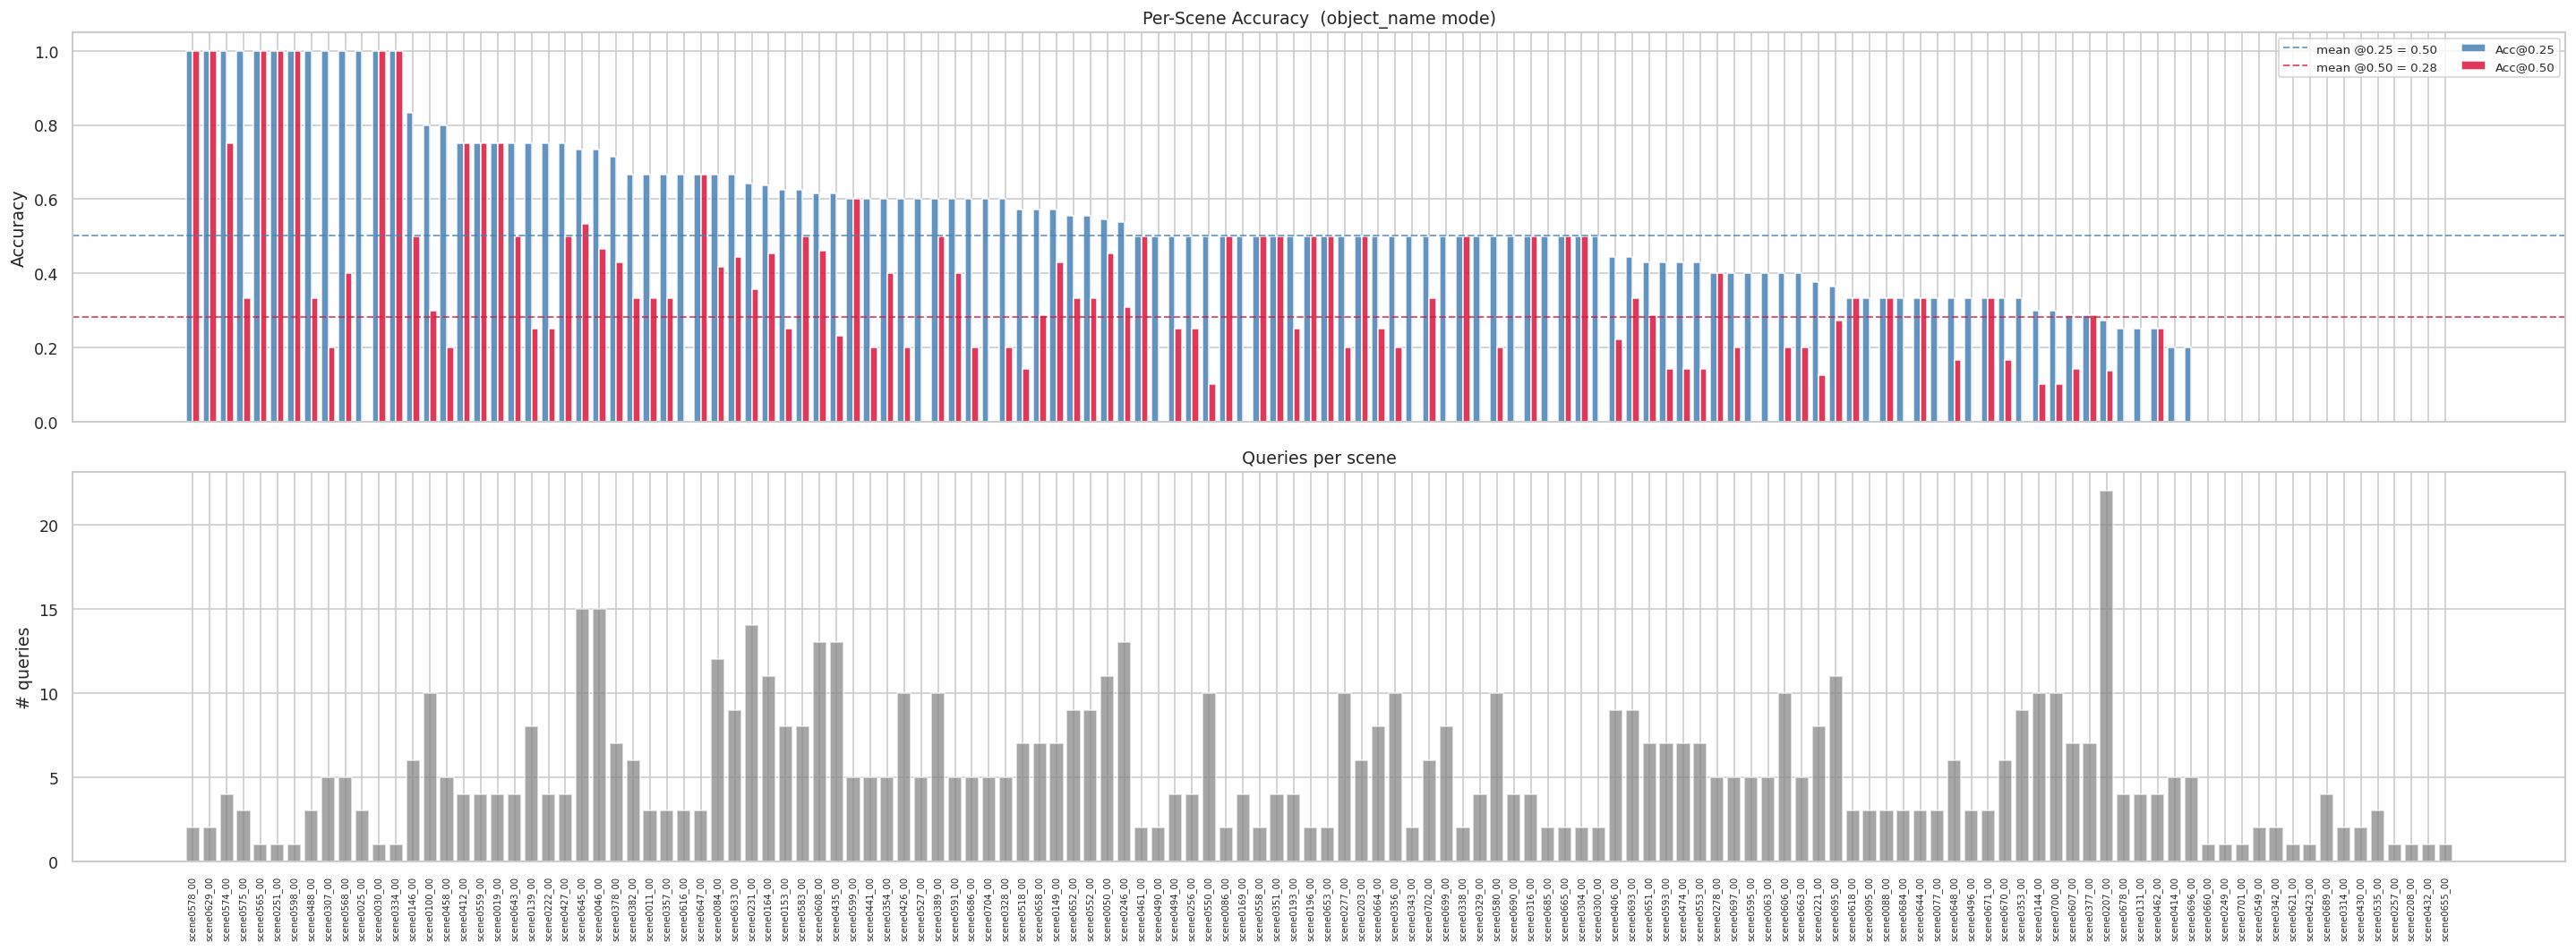

In [18]:
n_scenes = len(scene_df)
fig, axes = plt.subplots(2, 1, figsize=(max(14, n_scenes * 0.18), 9), sharex=True)

x = np.arange(n_scenes)
bar_w = 0.4

ax = axes[0]
ax.bar(x - bar_w/2, scene_df["acc@0.25"], bar_w, label="Acc@0.25", color="steelblue", alpha=0.85)
ax.bar(x + bar_w/2, scene_df["acc@0.50"], bar_w, label="Acc@0.50", color="crimson",   alpha=0.85)
ax.axhline(scene_df["acc@0.25"].mean(), color="steelblue", linewidth=1.2, linestyle="--",
           alpha=0.7, label=f"mean @0.25 = {scene_df['acc@0.25'].mean():.2f}")
ax.axhline(scene_df["acc@0.50"].mean(), color="crimson", linewidth=1.2, linestyle="--",
           alpha=0.7, label=f"mean @0.50 = {scene_df['acc@0.50'].mean():.2f}")
ax.set(ylabel="Accuracy", ylim=(0, 1.05), title=f"Per-Scene Accuracy  ({raw['query_mode']} mode)")
ax.legend(ncol=2, fontsize=8)

ax = axes[1]
ax.bar(x, scene_df["n"], color="gray", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(scene_df["scene_id"], rotation=90, fontsize=6)
ax.set(ylabel="# queries", title="Queries per scene")

plt.tight_layout()
plt.show()

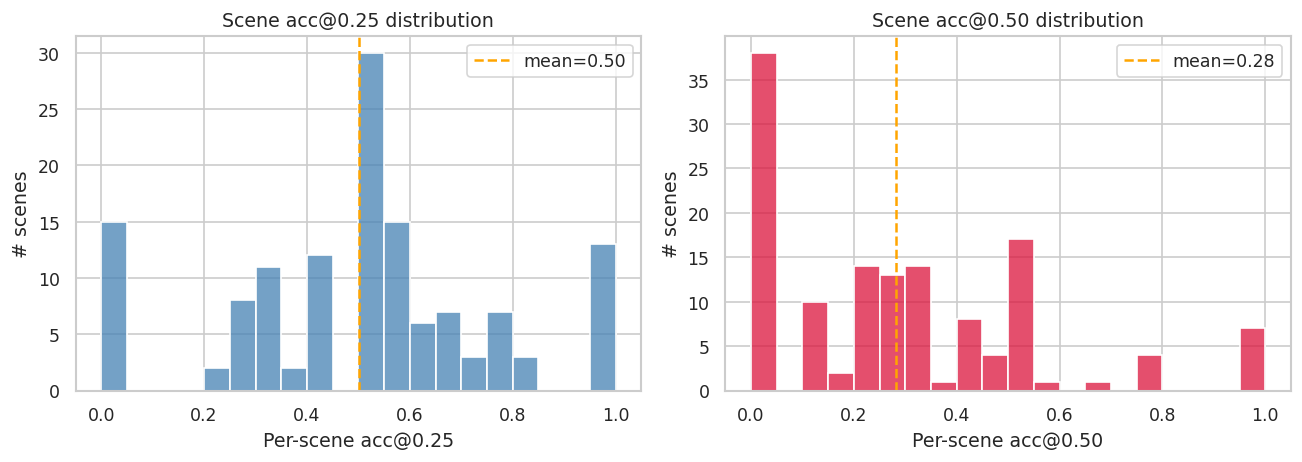

In [19]:
# distribution of per-scene accuracies
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, color in zip(axes, ["acc@0.25", "acc@0.50"], ["steelblue", "crimson"]):
    sns.histplot(scene_df[col], bins=20, ax=ax, color=color)
    ax.axvline(scene_df[col].mean(), color="orange", linewidth=1.5, linestyle="--",
               label=f"mean={scene_df[col].mean():.2f}")
    ax.set(xlabel=f"Per-scene {col}", ylabel="# scenes", title=f"Scene {col} distribution")
    ax.legend()

plt.tight_layout()
plt.show()

## 4 · Per-Object-Category Breakdown

In [20]:
cat_df = (
    df.groupby("category")
    .agg(
        n=("iou", "count"),
        mean_iou=("iou", "mean"),
        **{f"acc@{t:.2f}": (f"hit@{t:.2f}", "mean") for t in IOU_THRESHOLDS},
    )
    .query(f"n >= {MIN_CAT_COUNT}")
    .sort_values("acc@0.25", ascending=False)
    .reset_index()
)

cat_df.style.format({
    "mean_iou": "{:.3f}",
    **{f"acc@{t:.2f}": "{:.3f}" for t in IOU_THRESHOLDS},
}).background_gradient(subset=[f"acc@{t:.2f}" for t in IOU_THRESHOLDS], cmap="RdYlGn")

,category,n,mean_iou,acc@0.25,acc@0.50
0,copier,5,0.538,1.000,0.800
1,paper towel dispenser,5,0.485,1.000,0.400
2,tv,15,0.562,1.000,0.533
3,monitor,3,0.486,1.000,0.333
4,couch,14,0.497,0.929,0.571
5,bathtub,10,0.449,0.900,0.600
6,microwave,8,0.572,0.875,0.500
7,toilet,19,0.401,0.789,0.316
8,trash can,37,0.477,0.757,0.649
9,pillow,8,0.387,0.750,0.500


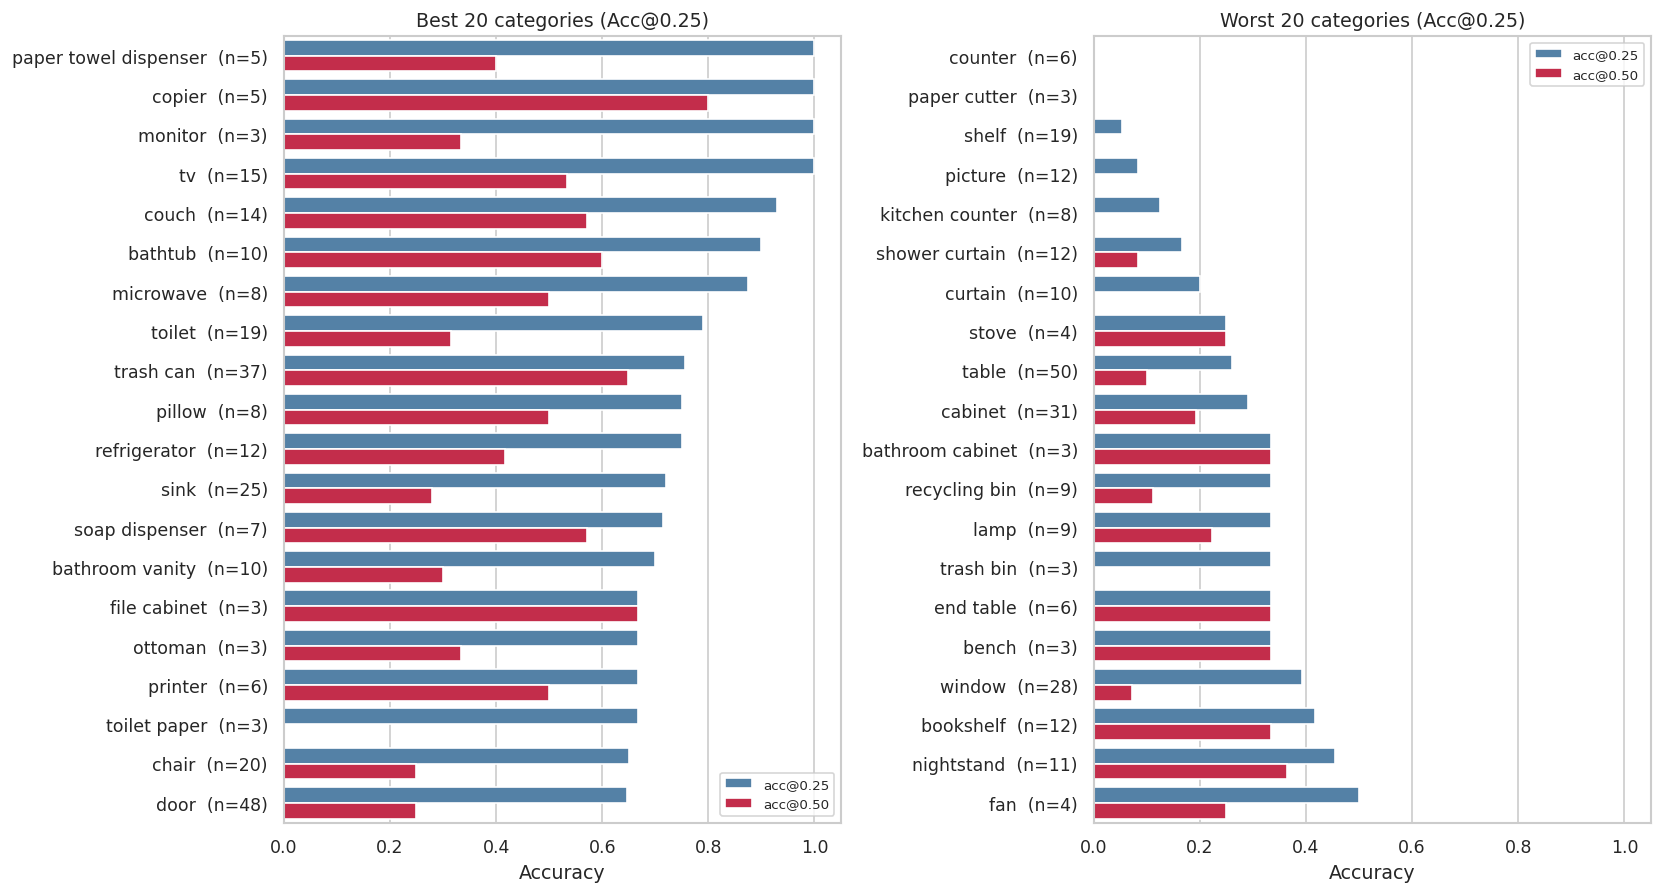

In [21]:
TOP_K = 20
top_cats    = cat_df.head(TOP_K)
bottom_cats = cat_df.tail(TOP_K).sort_values("acc@0.25")  # worst at top

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, TOP_K * 0.38)))

for ax, subset, title in [
    (axes[0], top_cats,    f"Best {TOP_K} categories (Acc@0.25)"),
    (axes[1], bottom_cats, f"Worst {TOP_K} categories (Acc@0.25)"),
]:
    plot_df = subset.melt(
        id_vars=["category", "n"],
        value_vars=[f"acc@{t:.2f}" for t in IOU_THRESHOLDS],
        var_name="threshold", value_name="accuracy",
    )
    plot_df["label"] = plot_df["category"] + "  (n=" + plot_df["n"].astype(str) + ")"
    sns.barplot(
        data=plot_df, y="label", x="accuracy", hue="threshold",
        palette=["steelblue", "crimson"], ax=ax,
        order=plot_df.groupby("label")["accuracy"].max().sort_values(ascending=(title.startswith("Worst"))).index,
    )
    ax.set(xlim=(0, 1.05), xlabel="Accuracy", ylabel="", title=title)
    ax.legend(title="", fontsize=8)

plt.tight_layout()
plt.show()

## 5 · Failure Analysis — Worst Items

In [22]:
SHOW_N = 30
worst = df.nsmallest(SHOW_N, "iou")[["scene_id", "object_id", "category", "iou", "query_text", "query_time_s"]]
worst.style.format({"iou": "{:.3f}", "query_time_s": "{:.1f}"}).background_gradient(subset=["iou"], cmap="RdYlGn")

,scene_id,object_id,category,iou,query_text,query_time_s
3,scene0019_00,11,lamp,0.000,lamp,17.9
11,scene0046_00,32,toilet flush button,0.000,toilet flush button,18.2
14,scene0046_00,19,table,0.000,table,18.4
30,scene0050_00,3,armchair,0.000,armchair,19.3
35,scene0050_00,29,stool,0.000,stool,18.1
39,scene0063_00,19,kitchen counter,0.000,kitchen counter,18.4
40,scene0063_00,11,door,0.000,door,18.6
46,scene0084_00,40,toilet seat cover dispenser,0.000,toilet seat cover dispenser,18.0
48,scene0084_00,29,seat,0.000,seat,18.2
57,scene0086_00,5,toilet seat cover dispenser,0.000,toilet seat cover dispenser,18.1


In [23]:
zero_iou = df[df["iou"] == 0.0]
print(f"Items with IoU = 0.0: {len(zero_iou)} / {n}  ({len(zero_iou)/n:.1%})")

# zero-IoU rate per category (categories with >= 2 items)
zero_rate = (
    df.assign(zero=(df["iou"] == 0.0))
    .groupby("category")
    .agg(n=("iou", "count"), zero_rate=("zero", "mean"))
    .query("n >= 2")
    .sort_values("zero_rate", ascending=False)
    .head(15)
)
zero_rate.style.format({"zero_rate": "{:.1%}"}).background_gradient(subset=["zero_rate"], cmap="Reds")

Items with IoU = 0.0: 165 / 722  (22.9%)


,n,zero_rate
category,,
toilet seat cover dispenser,2,100.0%
picture,12,83.3%
paper cutter,3,66.7%
recycling bin,9,66.7%
end table,6,66.7%
bookshelf,12,58.3%
mattress,2,50.0%
shower door,2,50.0%
kitchen cabinets,2,50.0%


## 6 · Query Timing

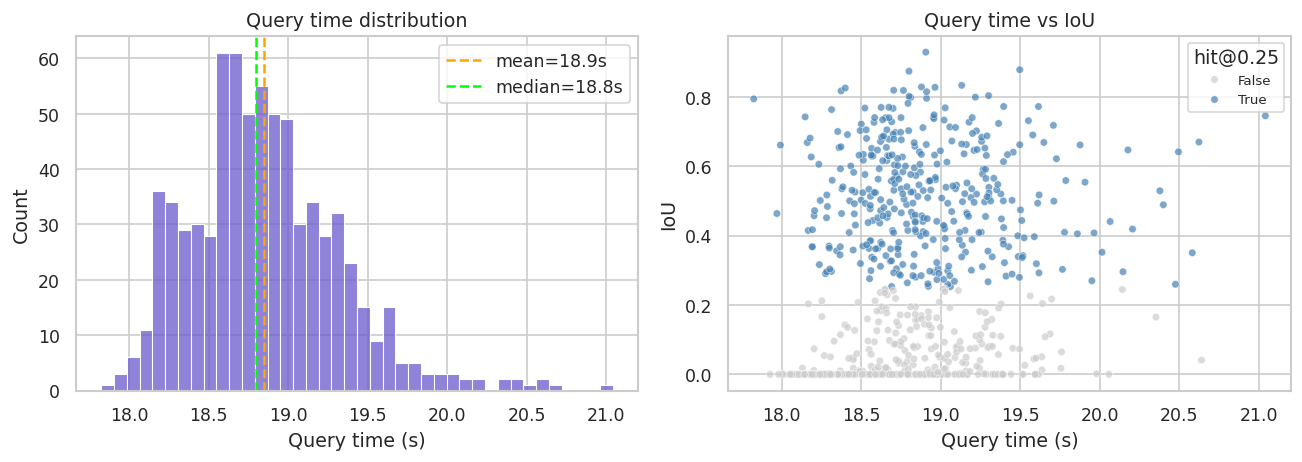

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
sns.histplot(df["query_time_s"], bins=40, ax=ax, color="slateblue")
ax.axvline(df["query_time_s"].mean(),   color="orange", linewidth=1.5, linestyle="--",
           label=f"mean={df['query_time_s'].mean():.1f}s")
ax.axvline(df["query_time_s"].median(), color="lime",   linewidth=1.5, linestyle="--",
           label=f"median={df['query_time_s'].median():.1f}s")
ax.set(xlabel="Query time (s)", ylabel="Count", title="Query time distribution")
ax.legend()

ax = axes[1]
sns.scatterplot(
    data=df, x="query_time_s", y="iou",
    hue="hit@0.25", palette={True: "steelblue", False: "#cccccc"},
    s=20, alpha=0.7, ax=ax, legend="full",
)
ax.set(xlabel="Query time (s)", ylabel="IoU", title="Query time vs IoU")
ax.legend(title="hit@0.25", fontsize=8)

plt.tight_layout()
plt.show()